# Modelado

In [77]:
import pandas as pd
import numpy as np 
import os

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn import metrics  

import statsmodels.api as sm

import warnings
warnings.filterwarnings('ignore')

## Funciones y utilidades

In [63]:
def carga_info(data):
    drop_cols = [
        'Municipio', 
        'Departamento', 
        'EVI_Min_Date', 
        'EVI_Max_Date', 
        'NDVI_Min_Date', 
        'NDVI_Max_Date', 
        'NDVI_Max_Count', 
        'Latitude', 
        'Longitude', 
        'Producto', 
        'Área Cosechada', 
        'Área Sembrada', 
        'Ciclo',
        'Producción'
        ]
    
    #Creación de nuevas variables necesarias
    data['Mpio'] = data['Municipio'].str.strip()+'_'+data['Departamento'].str.strip()
    data['Flag_covid'] = np.where(data['Year']==2020, 1, 0)
    data.rename(columns={'EVI_Max_Count':'Resolucion'}, inplace=True)
    #Eliminación de columnas innecesarias
    data.drop(columns=drop_cols, inplace=True)
    #Eliminación de nuelos -- esto puede cambiar si decidimos hacer imputacion
    data.dropna(inplace=True)
    #Ordenamiento
    data = data[['Year', 'Mpio', 't2m', 'd2m', 'tp', 'ssrd', 'e', 'stl1', 'Resolucion',
       'EVI_Min_Minimum', 'EVI_Max_Maximum', 'EVI_Avg_StdDev',
       'EVI_Median_Median', 'EVI_Avg_Mean', 'NDVI_Min_Minimum',
       'NDVI_Max_Maximum', 'NDVI_Avg_StdDev', 'NDVI_Median_Median',
       'NDVI_Avg_Mean', 'Flag_covid', 'Rendimiento']]
    
    print(f'Data cargada para {base}')
    data.info()
    return data

## 1.Carga de información

In [66]:
df_ago_nov = pd.read_excel("../Data anual/data_anual_ago_nov.xlsx")
df_sep_dec = pd.read_excel("../Data anual/data_anual_sep_dec.xlsx")
df_total = pd.read_excel("../Data anual/data_anual_total.xlsx")

df_ago_nov = carga_info(df_ago_nov)
df_sep_dec = carga_info(df_sep_dec)
df_total = carga_info(df_total)

Data cargada para ../Data anual/data_total.xlsx
<class 'pandas.core.frame.DataFrame'>
Index: 426 entries, 0 to 431
Data columns (total 21 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                426 non-null    int64  
 1   Mpio                426 non-null    object 
 2   t2m                 426 non-null    float64
 3   d2m                 426 non-null    float64
 4   tp                  426 non-null    float64
 5   ssrd                426 non-null    float64
 6   e                   426 non-null    float64
 7   stl1                426 non-null    float64
 8   Resolucion          426 non-null    int64  
 9   EVI_Min_Minimum     426 non-null    float64
 10  EVI_Max_Maximum     426 non-null    float64
 11  EVI_Avg_StdDev      426 non-null    float64
 12  EVI_Median_Median   426 non-null    float64
 13  EVI_Avg_Mean        426 non-null    float64
 14  NDVI_Min_Minimum    426 non-null    float64
 15  NDVI_Max_Maxim

## Relaciones lineales

In [ ]:
df_total_it = df_total[~df_total['Year'].isin([2024])]
df_total_it.drop(columns=['Year'], inplace=True)
df_total_it_dummies = pd.get_dummies(df_total_it, drop_first=True)

In [129]:
X_train, X_test, y_train, y_test = train_test_split(
    df_total_it_dummies.drop(columns=['Rendimiento']),
    df_total_it_dummies['Rendimiento'],
    test_size=0.2,
    random_state=42
)

predictors = X_train.columns

results = []

for pred in predictors:
    
    X = X_train[[pred]]
    if X.dtypes[0] != 'object':
        X = pd.get_dummies(X, drop_first=True)
    
    mod = sm.OLS(y_train, X)
    res = mod.fit()
    print("\n Resultados para predictor:",pred)
    print(res.summary())
    results.append({
        'predictor': pred,
        'R2': res.rsquared,
        'F_stat': res.fvalue,
        'coef': res.params[pred],
        'p_value': res.pvalues[pred],
    })

df_results = pd.DataFrame(results)
df_results.sort_values(by='R2', ascending=False, inplace=True)
df_results


 Resultados para predictor: t2m
                                 OLS Regression Results                                
Dep. Variable:            Rendimiento   R-squared (uncentered):                   0.917
Model:                            OLS   Adj. R-squared (uncentered):              0.917
Method:                 Least Squares   F-statistic:                              3540.
Date:                Sat, 25 Apr 2026   Prob (F-statistic):                   4.39e-175
Time:                        12:45:09   Log-Likelihood:                         -57.343
No. Observations:                 321   AIC:                                      116.7
Df Residuals:                     320   BIC:                                      120.5
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
--------

,predictor,R2,F_stat,coef,p_value
3,ssrd,0.923567,3866.683263,5.199519e-08,9.793987e-181
10,EVI_Median_Median,0.921618,3762.573353,2.046721e+00,5.510522e-179
13,NDVI_Max_Maximum,0.920422,3701.207428,1.057134e+00,6.221228e-178
11,EVI_Avg_Mean,0.920202,3690.118994,2.079819e+00,9.678372e-178
8,EVI_Max_Maximum,0.919752,3667.650186,1.384000e+00,2.378706e-177
15,NDVI_Median_Median,0.919109,3635.939916,1.269788e+00,8.536312e-177
4,e,0.918675,3614.806425,-2.880914e+02,2.011790e-176
16,NDVI_Avg_Mean,0.917942,3579.684794,1.313460e+00,8.448379e-176
0,t2m,0.917092,3539.718295,5.451661e-02,4.393358e-175
5,stl1,0.916955,3533.338698,5.431033e-02,5.725017e-175


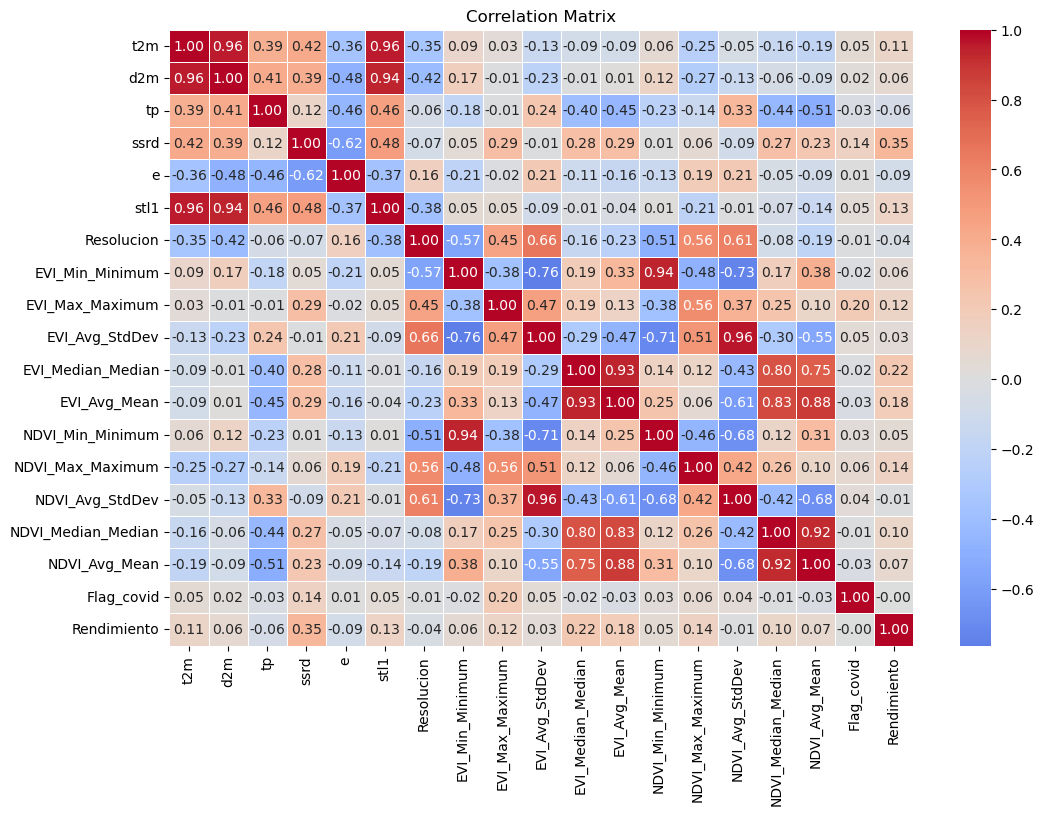

Rendimiento           1.000000
ssrd                  0.345375
EVI_Median_Median     0.222867
EVI_Avg_Mean          0.181461
NDVI_Max_Maximum      0.137152
stl1                  0.126328
EVI_Max_Maximum       0.120372
t2m                   0.113964
NDVI_Median_Median    0.101897
NDVI_Avg_Mean         0.074628
d2m                   0.064966
EVI_Min_Minimum       0.057137
NDVI_Min_Minimum      0.053289
EVI_Avg_StdDev        0.033591
Flag_covid           -0.003425
NDVI_Avg_StdDev      -0.007823
Resolucion           -0.039692
tp                   -0.062384
e                    -0.085023
Name: Rendimiento, dtype: float64

In [130]:
corr_df = df_total_it.drop(columns = ['Mpio']).corr()

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_df,
    cmap='coolwarm',
    center=0,
    annot=True,        # 👈 muestra los valores
    fmt=".2f",         # 👈 número de decimales
    linewidths=0.4
)

plt.title("Correlation Matrix")
plt.show()

corr_df['Rendimiento'].sort_values(ascending=False)

## En ensamble

In [131]:
X_train, X_test, y_train, y_test = train_test_split(
    df_total_it.drop(columns=['Rendimiento','Mpio']),
    df_total_it['Rendimiento'],
    test_size=0.2,
    random_state=42
)

RF = RandomForestRegressor(random_state=42)
RF.fit(X_train, y_train)
feat_imp_df = pd.DataFrame({
    'feature': RF.feature_names_in_,
    'importance': RF.feature_importances_
})

# ordenar de mayor a menor
feat_imp_df = feat_imp_df.sort_values(by='importance', ascending=False)

feat_imp_df

,feature,importance
3,ssrd,0.165840
10,EVI_Median_Median,0.139340
13,NDVI_Max_Maximum,0.075716
2,tp,0.062001
12,NDVI_Min_Minimum,0.056726
8,EVI_Max_Maximum,0.055688
4,e,0.051751
11,EVI_Avg_Mean,0.049631
9,EVI_Avg_StdDev,0.047478
15,NDVI_Median_Median,0.044580
